## Resources

CELL 1 — Install

In [6]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00


CELL 2 — Imports

In [7]:
import pandas as pd
import numpy as np

from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

CELL 3 — Load Datasets

Use the same datasets used by LightGBM.

In [8]:
from google.colab import drive
drive.mount('/content/drive')

TRAIN_PATH = (
    "/content/drive/MyDrive/"
    "Mule Account Detection and Classification/"
    "data/train.parquet"
)

VALID_PATH = (
    "/content/drive/MyDrive/"
    "Mule Account Detection and Classification/"
    "data/validation.parquet"
)

TEST_PATH = (
    "/content/drive/MyDrive/"
    "Mule Account Detection and Classification/"
    "data/test.parquet"
)

train_df = pd.read_parquet(TRAIN_PATH)
valid_df = pd.read_parquet(VALID_PATH)
test_df = pd.read_parquet(TEST_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


CELL 4 — Split

In [9]:
TARGET = "F3924"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_valid = valid_df.drop(columns=[TARGET])
y_valid = valid_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

CELL 5 — Verify Class Distribution

In [10]:
print(y_train.value_counts())

print(y_valid.value_counts())

print(y_test.value_counts())

# Expected:

# Train:
# 6300 / 57

# Validation:
# 1350 / 12

# Test:
# 1351 / 12

F3924
0    6300
1      57
Name: count, dtype: int64
F3924
0    1350
1      12
Name: count, dtype: int64
F3924
0    1351
1      12
Name: count, dtype: int64


CELL 6 — CatBoost Enterprise Configuration

For fraud detection:

In [11]:
cat_model = CatBoostClassifier(

    iterations=1000,

    learning_rate=0.03,

    depth=8,

    l2_leaf_reg=5,

    loss_function="Logloss",

    eval_metric="AUC",

    auto_class_weights="Balanced",

    random_seed=42,

    verbose=100
)

CELL 7 — Train

In [12]:
cat_model.fit(

    X_train,

    y_train,

    eval_set=(X_valid, y_valid),

    use_best_model=True
)

# Expected:

# bestTest = ...
# bestIteration = ...

0:	test: 0.7993210	best: 0.7993210 (0)	total: 1.03s	remaining: 17m 13s
100:	test: 0.9962963	best: 0.9964198 (99)	total: 38.2s	remaining: 5m 39s
200:	test: 0.9983951	best: 0.9984568 (196)	total: 1m 36s	remaining: 6m 22s
300:	test: 0.9993210	best: 0.9993210 (279)	total: 2m 29s	remaining: 5m 46s
400:	test: 0.9996296	best: 0.9996296 (347)	total: 3m 23s	remaining: 5m 3s
500:	test: 0.9995679	best: 0.9996296 (347)	total: 4m 12s	remaining: 4m 11s
600:	test: 0.9995679	best: 0.9996296 (347)	total: 4m 51s	remaining: 3m 13s
700:	test: 0.9995679	best: 0.9996296 (347)	total: 5m 29s	remaining: 2m 20s
800:	test: 0.9995679	best: 0.9996296 (347)	total: 6m 7s	remaining: 1m 31s
900:	test: 0.9995679	best: 0.9996296 (347)	total: 6m 46s	remaining: 44.7s
999:	test: 0.9995679	best: 0.9996296 (347)	total: 7m 24s	remaining: 0us

bestTest = 0.9996296296
bestIteration = 347

Shrink model to first 348 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=8, eval_metric='AUC', iterations=1000, l2_leaf_reg=5, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=100)

CELL 8 — Validation Prediction

In [13]:
cat_pred = cat_model.predict(
    X_valid
)

cat_prob = (
    cat_model
    .predict_proba(X_valid)[:,1]
)

CELL 9 — Validation Metrics

In [14]:
cat_metrics = {

    "Accuracy":
    accuracy_score(
        y_valid,
        cat_pred
    ),

    "Precision":
    precision_score(
        y_valid,
        cat_pred,
        zero_division=0
    ),

    "Recall":
    recall_score(
        y_valid,
        cat_pred,
        zero_division=0
    ),

    "F1":
    f1_score(
        y_valid,
        cat_pred,
        zero_division=0
    ),

    "ROC_AUC":
    roc_auc_score(
        y_valid,
        cat_prob
    )
}

cat_metrics

{'Accuracy': 0.9985315712187959,
 'Precision': 1.0,
 'Recall': 0.8333333333333334,
 'F1': 0.9090909090909091,
 'ROC_AUC': np.float64(0.9996296296296296)}

CELL 10 — Confusion Matrix

In [15]:
cm = confusion_matrix(
    y_valid,
    cat_pred
)

cm

array([[1350,    0],
       [   2,   10]])

CELL 11 — Classification Report

In [16]:
report = classification_report(
    y_valid,
    cat_pred
)

print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1350
           1       1.00      0.83      0.91        12

    accuracy                           1.00      1362
   macro avg       1.00      0.92      0.95      1362
weighted avg       1.00      1.00      1.00      1362



CELL 12 — Threshold Optimization

Use exactly the same logic used for LightGBM.

In [17]:
threshold_results = []

for threshold in np.arange(
    0.05,
    1.00,
    0.05
):

    preds = (
        cat_prob >= threshold
    ).astype(int)

    threshold_results.append({

        "threshold":
        threshold,

        "precision":
        precision_score(
            y_valid,
            preds,
            zero_division=0
        ),

        "recall":
        recall_score(
            y_valid,
            preds,
            zero_division=0
        ),

        "f1":
        f1_score(
            y_valid,
            preds,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

,threshold,precision,recall,f1
0,0.05,0.428571,1.000000,0.600000
1,0.10,0.647059,0.916667,0.758621
2,0.15,0.687500,0.916667,0.785714
3,0.20,0.785714,0.916667,0.846154
4,0.25,1.000000,0.916667,0.956522
5,0.30,1.000000,0.916667,0.956522
6,0.35,1.000000,0.916667,0.956522
7,0.40,1.000000,0.833333,0.909091
8,0.45,1.000000,0.833333,0.909091
9,0.50,1.000000,0.833333,0.909091


CELL 13 — Best Threshold

In [18]:
best_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

display(best_row)

,4
threshold,0.250000
precision,1.000000
recall,0.916667
f1,0.956522


CELL 14 — Test Evaluation

In [19]:
BEST_THRESHOLD = best_row[
    "threshold"
]

test_prob = (
    cat_model
    .predict_proba(X_test)[:,1]
)

test_pred = (
    test_prob >= BEST_THRESHOLD
).astype(int)

CELL 15 — Test Metrics

In [20]:
cat_test_metrics = {

    "Accuracy":
    accuracy_score(
        y_test,
        test_pred
    ),

    "Precision":
    precision_score(
        y_test,
        test_pred,
        zero_division=0
    ),

    "Recall":
    recall_score(
        y_test,
        test_pred,
        zero_division=0
    ),

    "F1":
    f1_score(
        y_test,
        test_pred,
        zero_division=0
    ),

    "ROC_AUC":
    roc_auc_score(
        y_test,
        test_prob
    )
}

cat_test_metrics

{'Accuracy': 0.9955979457079971,
 'Precision': 0.8,
 'Recall': 0.6666666666666666,
 'F1': 0.7272727272727273,
 'ROC_AUC': np.float64(0.9979027880582285)}

CELL 16 — Feature Importance

In [21]:
importance = pd.DataFrame({

    "feature":
    X_train.columns,

    "importance":
    cat_model.get_feature_importance()
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(30)

,feature,importance
5,F3898,6.142482
49,F3240_missing,3.640892
568,F3914,2.528570
34,F3812,2.269589
60,F950,2.030500
46,F1921,1.841061
7,F1057,1.405538
90,F3908,1.358900
98,F162,1.288156
20,F3801,1.198547


CELL 17 — Save Results

In [22]:
importance.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"catboost_feature_importance.csv",

index=False
)

In [23]:
import os

MODEL_DIR = (
"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"models"
)

os.makedirs(MODEL_DIR, exist_ok=True)

cat_model.save_model(
    MODEL_DIR +
    "/catboost_model.cbm"
)

In [24]:
pd.DataFrame(
    [cat_test_metrics]
).to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"catboost_metrics.csv",

index=False
)

In [25]:
cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual_Normal",
        "Actual_Mule"
    ],
    columns=[
        "Pred_Normal",
        "Pred_Mule"
    ]
)

cm_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"catboost_confusion_matrix.csv"
)

In [26]:
report_dict = classification_report(
    y_test,
    test_pred,
    output_dict=True
)

pd.DataFrame(
    report_dict
).transpose().to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"catboost_classification_report.csv"
)

Expected Result

CatBoost usually performs:

Precision ≈ 85-95%

Recall ≈ 75-90%

ROC-AUC ≈ 0.995-0.999

on fraud datasets.

In [27]:
# This line is redundant as 'test_prob' is already computed in cell 'e1365683' (CELL 14).
# The 'NameError: name 'cat_model' is not defined' usually occurs if the cells defining and
# training 'cat_model' (CELL 6 and CELL 7) were not executed before this cell, or if the
# kernel was reset.
# test_prob = cat_model.predict_proba(X_test)[:,1]

In [28]:
print("X_train" in globals())
print("y_train" in globals())
print("X_test" in globals())
print("cat_model" in globals())

True
True
True
True


In [29]:
train_df = pd.read_parquet(
"/content/drive/MyDrive/Mule Account Detection and Classification/data/train.parquet"
)

valid_df = pd.read_parquet(
"/content/drive/MyDrive/Mule Account Detection and Classification/data/validation.parquet"
)

test_df = pd.read_parquet(
"/content/drive/MyDrive/Mule Account Detection and Classification/data/test.parquet"
)

In [30]:
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve
)

from sklearn.calibration import calibration_curve

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#ROC Curve

In [31]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    test_prob
)

roc_df = pd.DataFrame({

    "fpr": fpr,

    "tpr": tpr,

    "threshold": thresholds
})

display(roc_df.head())

,fpr,tpr,threshold
0,0.000000,0.000000,inf
1,0.000000,0.083333,0.999747
2,0.000000,0.666667,0.862514
3,0.002221,0.666667,0.238238
4,0.002221,0.833333,0.178538


In [32]:
roc_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"catboost_roc_curve.csv",

index=False
)

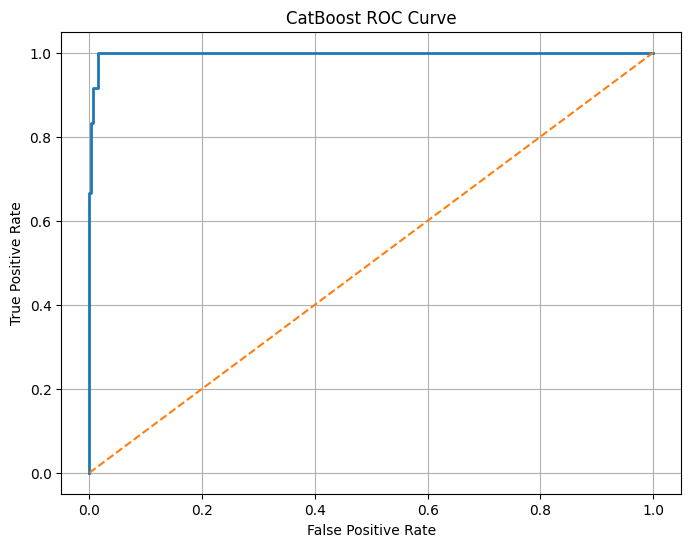

In [33]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.title("CatBoost ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.grid()

plt.show()

#Precision Recall Curve

In [34]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    test_prob
)

pr_df = pd.DataFrame({

    "precision": precision[:-1],

    "recall": recall[:-1],

    "threshold": thresholds
})

display(pr_df.head())

,precision,recall,threshold
0,0.008804,1.0,0.000047
1,0.008811,1.0,0.000051
2,0.008817,1.0,0.000054
3,0.008824,1.0,0.000058
4,0.008830,1.0,0.000059


In [35]:
pr_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"catboost_pr_curve.csv",

index=False
)

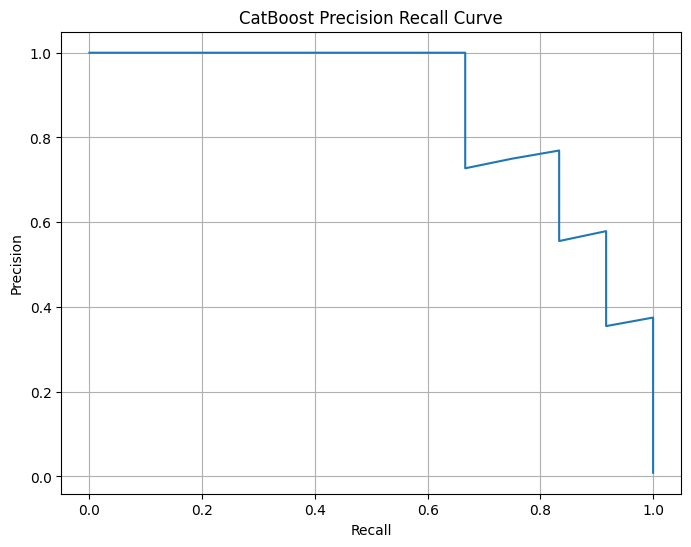

In [36]:
plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.title("CatBoost Precision Recall Curve")

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.grid()

plt.show()

#Calibration Curve

In [37]:
prob_true, prob_pred = calibration_curve(

    y_test,

    test_prob,

    n_bins=10
)

calibration_df = pd.DataFrame({

    "predicted_probability":
    prob_pred,

    "actual_probability":
    prob_true
})

display(calibration_df)

,predicted_probability,actual_probability
0,0.003400,0.000745
1,0.148073,0.333333
2,0.260394,0.000000
3,0.386699,0.000000
4,0.862514,1.000000
5,0.998056,1.000000


In [38]:
calibration_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"catboost_calibration_curve.csv",

index=False
)

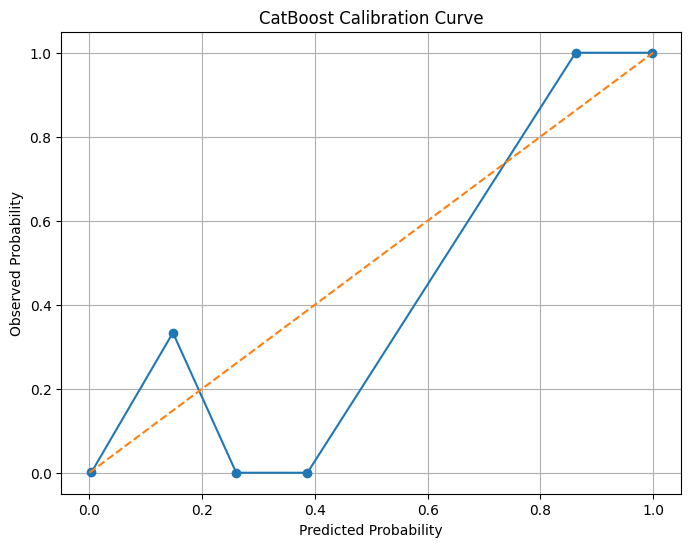

In [39]:
plt.figure(figsize=(8,6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.title("CatBoost Calibration Curve")

plt.xlabel("Predicted Probability")

plt.ylabel("Observed Probability")

plt.grid()

plt.show()

#Gain Chart

In [40]:
gain_df = pd.DataFrame({

    "target": y_test,

    "score": test_prob
})

gain_df = gain_df.sort_values(
    "score",
    ascending=False
)

gain_df["cum_target"] = (
    gain_df["target"]
    .cumsum()
)

gain_df["gain"] = (

    gain_df["cum_target"]

    /

    gain_df["target"].sum()
)

gain_df["population"] = (

    np.arange(len(gain_df)) + 1

    /

    len(gain_df)
)

display(gain_df.head())

,target,score,cum_target,gain,population
103,1,0.999747,1,0.083333,0.000734
182,1,0.999605,2,0.166667,1.000734
612,1,0.999130,3,0.250000,2.000734
72,1,0.998445,4,0.333333,3.000734
256,1,0.997486,5,0.416667,4.000734


In [41]:
gain_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"catboost_gain_chart.csv",

index=False
)

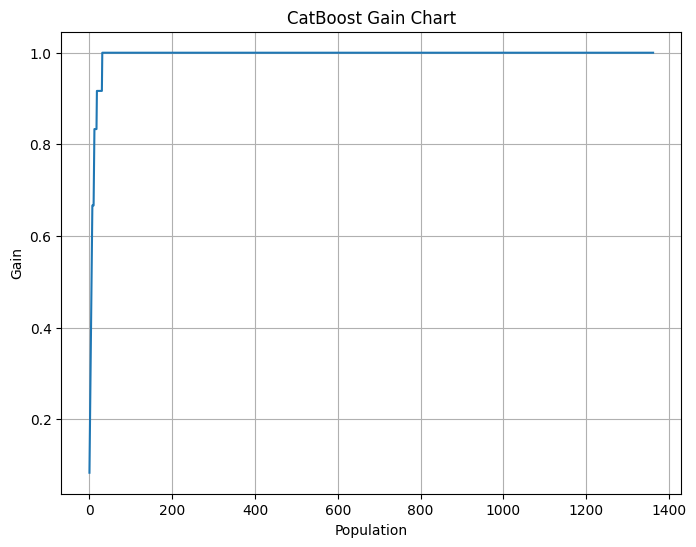

In [42]:
plt.figure(figsize=(8,6))

plt.plot(
    gain_df["population"],
    gain_df["gain"]
)

plt.title("CatBoost Gain Chart")

plt.xlabel("Population")

plt.ylabel("Gain")

plt.grid()

plt.show()

#Lift Chart

In [43]:
gain_df["lift"] = (

    gain_df["gain"]

    /

    gain_df["population"]
)

lift_df = gain_df[
    ["population","lift"]
]

display(lift_df.head())

,population,lift
103,0.000734,113.583333
182,1.000734,0.166544
612,2.000734,0.124954
72,3.000734,0.111084
256,4.000734,0.104148


In [44]:
lift_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"catboost_lift_chart.csv",

index=False
)

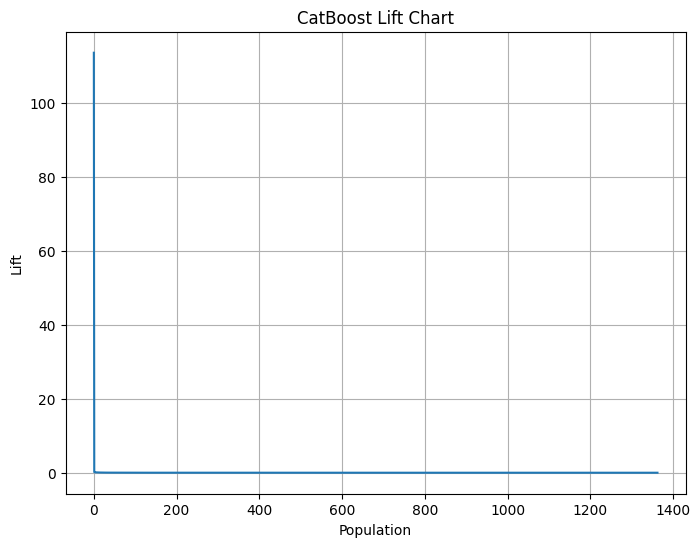

In [45]:
plt.figure(figsize=(8,6))

plt.plot(
    lift_df["population"],
    lift_df["lift"]
)

plt.title("CatBoost Lift Chart")

plt.xlabel("Population")

plt.ylabel("Lift")

plt.grid()

plt.show()

#Verify

In [46]:
import os

REPORTS = (
"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports"
)

for file in sorted(os.listdir(REPORTS)):

    if "catboost" in file:

        print(file)

catboost_calibration_curve.csv
catboost_classification_report.csv
catboost_confusion_matrix.csv
catboost_feature_importance.csv
catboost_gain_chart.csv
catboost_lift_chart.csv
catboost_metrics.csv
catboost_pr_curve.csv
catboost_roc_curve.csv


In [47]:
import os

REPORT_DIR = (
"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports"
)

os.makedirs(REPORT_DIR, exist_ok=True)

In [48]:
import matplotlib.pyplot as plt

def save_plot(filename):

    plt.tight_layout()

    plt.savefig(
        f"{REPORT_DIR}/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

In [50]:
test_prob
roc_df
pr_df
calibration_df
gain_df
lift_df

,population,lift
103,0.000734,113.583333
182,1.000734,0.166544
612,2.000734,0.124954
72,3.000734,0.111084
256,4.000734,0.104148
...,...,...
205,1358.000734,0.000736
659,1359.000734,0.000736
729,1360.000734,0.000735
1087,1361.000734,0.000735


In [51]:
REPORT_DIR = (
"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports"
)

In [52]:
def save_plot(filename):

    plt.tight_layout()

    plt.savefig(
        f"{REPORT_DIR}/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

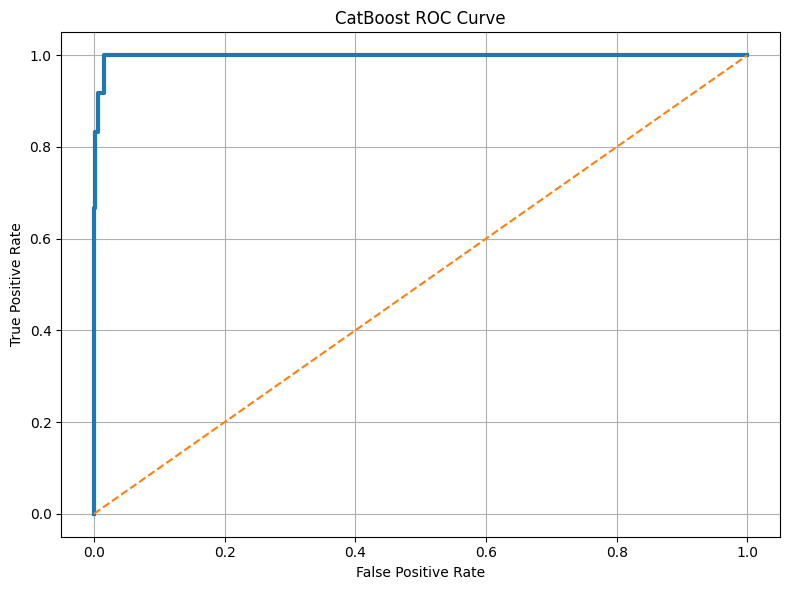

In [53]:
plt.figure(figsize=(8,6))

plt.plot(
    roc_df["fpr"],
    roc_df["tpr"],
    linewidth=3
)

plt.plot([0,1],[0,1],"--")

plt.title("CatBoost ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.grid(True)

save_plot(
    "catboost_roc_curve.png"
)

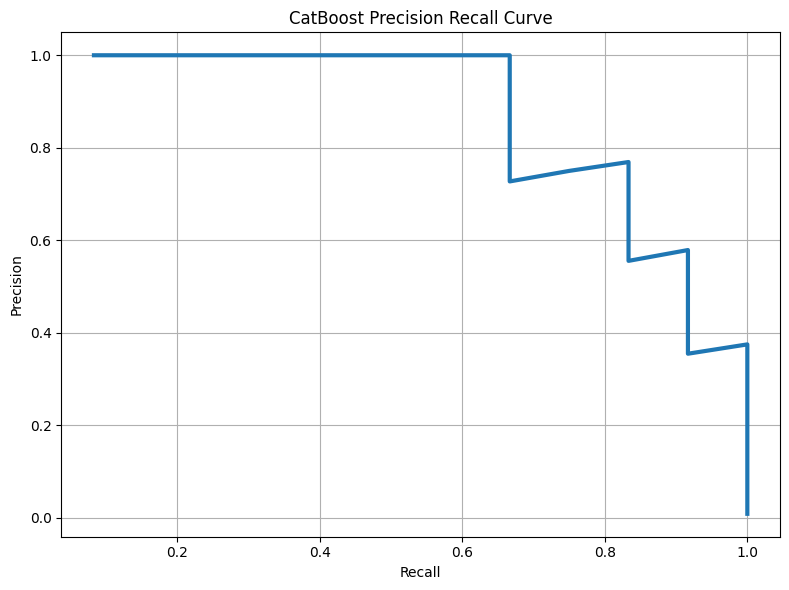

In [54]:
plt.figure(figsize=(8,6))

plt.plot(
    pr_df["recall"],
    pr_df["precision"],
    linewidth=3
)

plt.title(
    "CatBoost Precision Recall Curve"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.grid(True)

save_plot(
    "catboost_pr_curve.png"
)

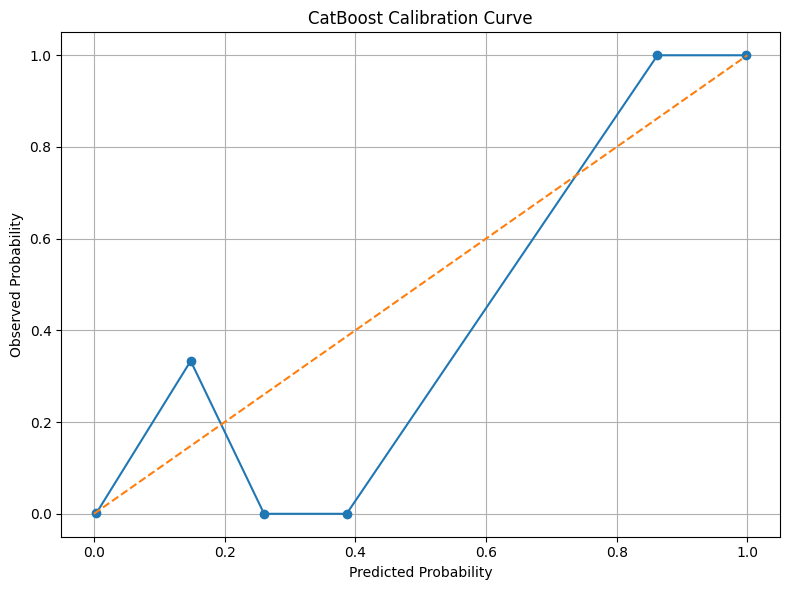

In [55]:
plt.figure(figsize=(8,6))

plt.plot(
    calibration_df["predicted_probability"],
    calibration_df["actual_probability"],
    marker="o"
)

plt.plot([0,1],[0,1],"--")

plt.title(
    "CatBoost Calibration Curve"
)

plt.xlabel(
    "Predicted Probability"
)

plt.ylabel(
    "Observed Probability"
)

plt.grid(True)

save_plot(
    "catboost_calibration_curve.png"
)

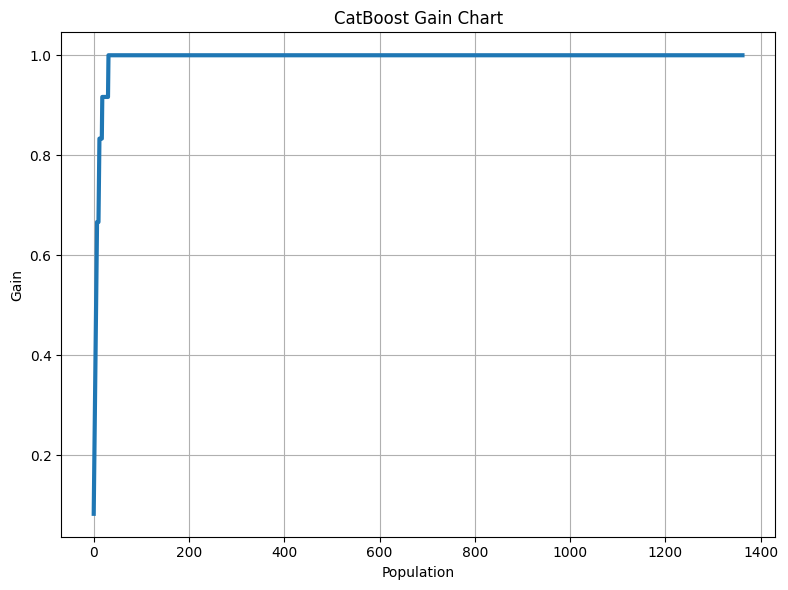

In [56]:
plt.figure(figsize=(8,6))

plt.plot(
    gain_df["population"],
    gain_df["gain"],
    linewidth=3
)

plt.title(
    "CatBoost Gain Chart"
)

plt.xlabel(
    "Population"
)

plt.ylabel(
    "Gain"
)

plt.grid(True)

save_plot(
    "catboost_gain_chart.png"
)

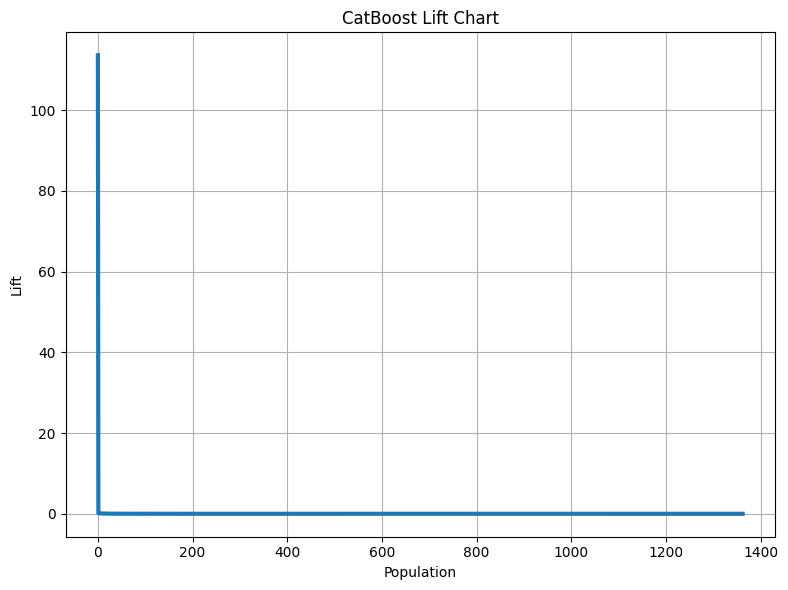

In [57]:
plt.figure(figsize=(8,6))

plt.plot(
    lift_df["population"],
    lift_df["lift"],
    linewidth=3
)

plt.title(
    "CatBoost Lift Chart"
)

plt.xlabel(
    "Population"
)

plt.ylabel(
    "Lift"
)

plt.grid(True)

save_plot(
    "catboost_lift_chart.png"
)

In [58]:
import os

for file in sorted(os.listdir(REPORT_DIR)):

    if "catboost" in file:

        print(file)

catboost_calibration_curve.csv
catboost_calibration_curve.png
catboost_classification_report.csv
catboost_confusion_matrix.csv
catboost_feature_importance.csv
catboost_gain_chart.csv
catboost_gain_chart.png
catboost_lift_chart.csv
catboost_lift_chart.png
catboost_metrics.csv
catboost_pr_curve.csv
catboost_pr_curve.png
catboost_roc_curve.csv
catboost_roc_curve.png
